In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [14]:
# We will each column a name from glass.names as glass.data has no header
column_names = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'GlassType']

# Now we will load the data from the glass.data file which has comma separated values.
# The `header=None` means our file doesn't have a row with column names.
df = pd.read_csv('data/glass.data', header=None, names=column_names)
df.head()


,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,GlassType
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [15]:
# Dropping 'Id' column.
df = df.drop('Id', axis=1)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,GlassType
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
X = df.drop('GlassType', axis=1)
y = df['GlassType']

X.shape, y.shape

((214, 9), (214,))

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((171, 9), (43, 9), (171,), (43,))

In [ ]:
# Random Forest pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [23]:
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_rf

array([1, 7, 1, 7, 2, 2, 1, 2, 2, 1, 6, 2, 1, 2, 6, 5, 7, 1, 1, 6, 2, 7,
       7, 7, 3, 2, 1, 1, 5, 1, 1, 2, 3, 2, 1, 7, 5, 1, 1, 7, 1, 7, 1])

In [31]:
# Performance of Random Forest model

print("Results for the Random Forest Model")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Results for the Random Forest Model
Accuracy: 0.8372
[[11  0  0  0  0  0]
 [ 4  9  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]
              precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.90      0.64      0.75        14
           3       1.00      0.67      0.80         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.84        43
   macro avg       0.91      0.84      0.86        43
weighted avg       0.87      0.84      0.83        43



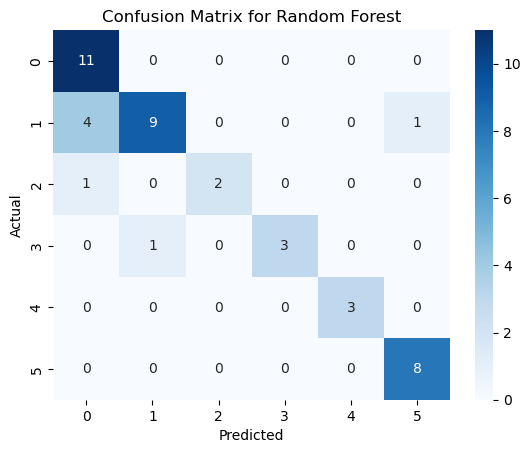

In [36]:
# Visualizing the confusion matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [37]:
# SVM pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(random_state=42))
])
svm_pipeline


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(random_state=42))])

In [38]:
svm_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(random_state=42))])

In [39]:
y_pred_svm = svm_pipeline.predict(X_test)
y_pred_svm


array([1, 7, 1, 7, 2, 2, 1, 2, 2, 2, 5, 2, 1, 2, 6, 5, 6, 1, 1, 2, 2, 7,
       7, 7, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 7, 5, 1, 1, 2, 1, 7, 1])

In [40]:
# Performance of SVM model

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

print(confusion_matrix(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy: 0.7209
[[11  0  0  0  0  0]
 [ 4 10  0  0  0  0]
 [ 1  2  0  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  1  0  1  1  0]
 [ 0  0  0  0  1  7]]
              precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.67      0.71      0.69        14
           3       0.00      0.00      0.00         3
           5       0.67      0.50      0.57         4
           6       0.50      0.33      0.40         3
           7       1.00      0.88      0.93         8

    accuracy                           0.72        43
   macro avg       0.59      0.57      0.57        43
weighted avg       0.68      0.72      0.69        43



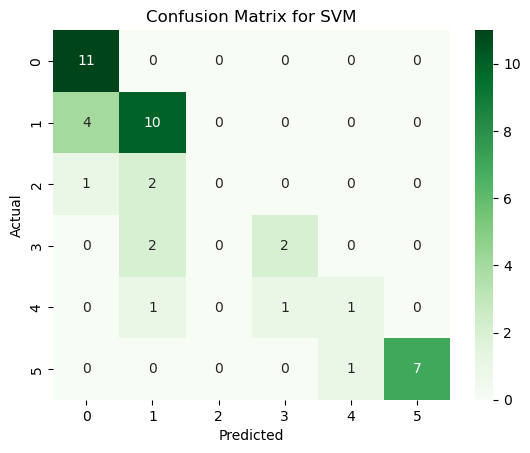

In [41]:
# Visualizing the confusion matrix for SVM
plt.figure()
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()